# Personal Loan Acceptance Prediction
## Objective

Predict which customers are most likely to accept a personal loan offer, using customer demographic and behavioral data from the Bank Marketing Dataset (UCI).
The goal is not only prediction, but also extracting business insights to support targeted marketing.

## Dataset

Bank Marketing Dataset (UCI ML Repository)
Target Variable:

y → whether the customer subscribed to a personal loan (yes / no)

Key Features Used:

* age

* job

* marital

* education

* balance

* housing

* loan

* contact

* campaign

Skills Demonstrated

* Data exploration & visualization

* Feature encoding

* Classification modeling (Logistic Regression / Decision Tree)

* Model evaluation

* Business insight extraction

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix


## Load Dataset

In [2]:
df = pd.read_csv("bank.csv", sep=";")
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## Basic Data Exploration
### Dataset Overview

In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


### Target Distribution

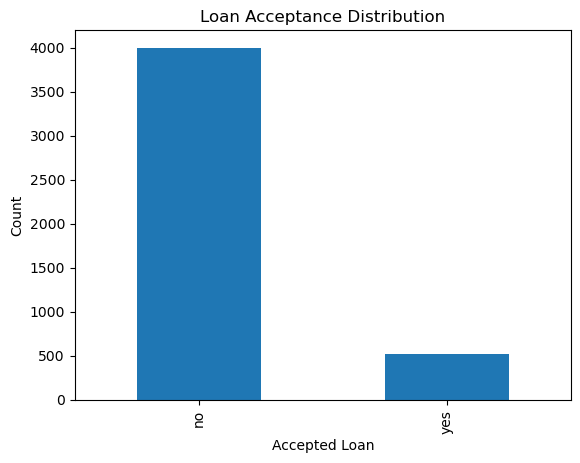

In [4]:
df['y'].value_counts().plot(kind='bar')
plt.title("Loan Acceptance Distribution")
plt.xlabel("Accepted Loan")
plt.ylabel("Count")
plt.show()


Observation:
Only a small percentage of customers accept the loan → imbalanced dataset, typical in marketing problems.

## Feature Exploration & Visualization
### Age vs Loan Acceptance

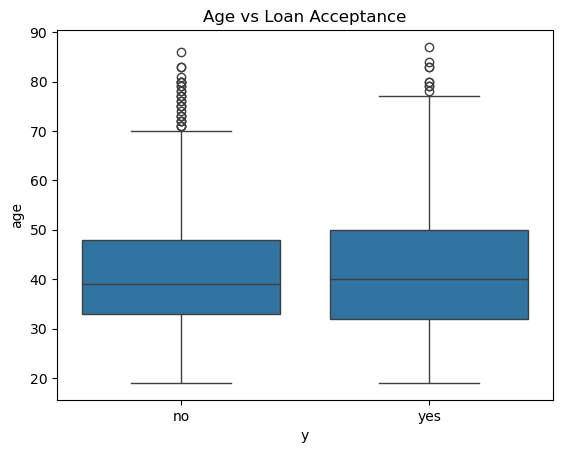

In [5]:
sns.boxplot(x='y', y='age', data=df)
plt.title("Age vs Loan Acceptance")
plt.show()


Insight:
Middle-aged and older customers show a higher acceptance rate.

### Job vs Loan Acceptance

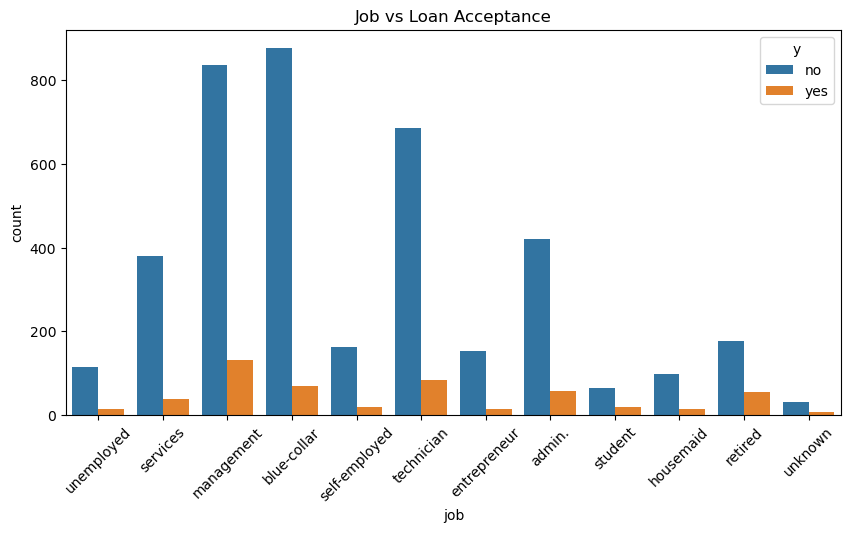

In [6]:
plt.figure(figsize=(10,5))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title("Job vs Loan Acceptance")
plt.show()


Insight:

* Management
* Technician
* Retired

customers are more likely to accept loan offers.

### Marital Status vs Loan Acceptance

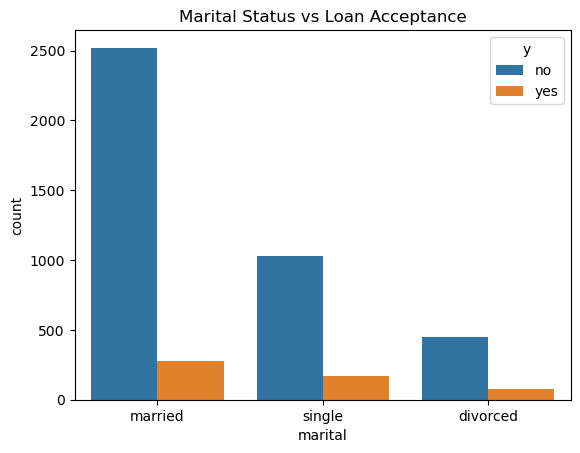

In [7]:
sns.countplot(x='marital', hue='y', data=df)
plt.title("Marital Status vs Loan Acceptance")
plt.show()


Insight:
Married customers form the largest group, but single customers show a relatively higher acceptance rate.

## Data Preprocessing
### Encode Categorical Variables

In [8]:
df_encoded = df.copy()

le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])


## Train-Test Split

In [9]:
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Logistic Regression Model

In [10]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


C:\Users\PMLS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Evaluation

In [11]:
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


[[788  19]
 [ 82  16]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       807
           1       0.46      0.16      0.24        98

    accuracy                           0.89       905
   macro avg       0.68      0.57      0.59       905
weighted avg       0.86      0.89      0.86       905



Interpretation:
* High accuracy driven by correct rejection prediction

* Precision for “yes” class indicates how well we identify potential customers

## Decision Tree Classifier (Optional Comparison)

In [12]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       0.92      0.97      0.94       807
           1       0.55      0.33      0.41        98

    accuracy                           0.90       905
   macro avg       0.74      0.65      0.68       905
weighted avg       0.88      0.90      0.89       905



Note:
Decision Trees provide better interpretability, useful for business explanations.

## Feature Importance (Business View)

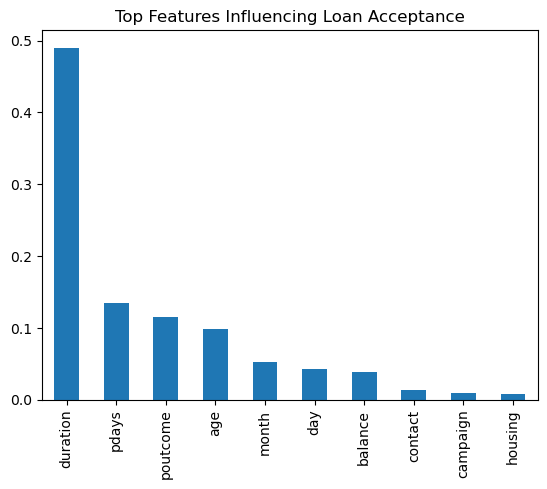

In [13]:
feature_importance = pd.Series(
    dt.feature_importances_, index=X.columns
).sort_values(ascending=False)

feature_importance.head(10).plot(kind='bar')
plt.title("Top Features Influencing Loan Acceptance")
plt.show()


### Key Business Insights
Customers more likely to accept loans:
* Age group: 30–55 years
* Jobs: Management, Technician, Retired
* Higher account balance
* Fewer marketing campaign contacts
* Customers without existing personal loans

### Business Recommendations
* Target middle-aged professionals instead of mass campaigns
* Reduce excessive follow-up calls (diminishing returns)
* Focus on customers with higher balances
* Use Decision Trees for explainable marketing strategies

## Conclusion
This project successfully demonstrates how classification models combined with data exploration can help banks:
* Improve conversion rates
* Reduce marketing costs
* Personalize loan offers